<a href="https://colab.research.google.com/github/dayananathalih-prog/EstadisticaVerano2026/blob/main/Studentperformance/STUDENTPERFORMANCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/dayananathalih-prog/EstadisticaVerano2026/refs/heads/main/Studentperformance/Student_Performance.csv")

df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


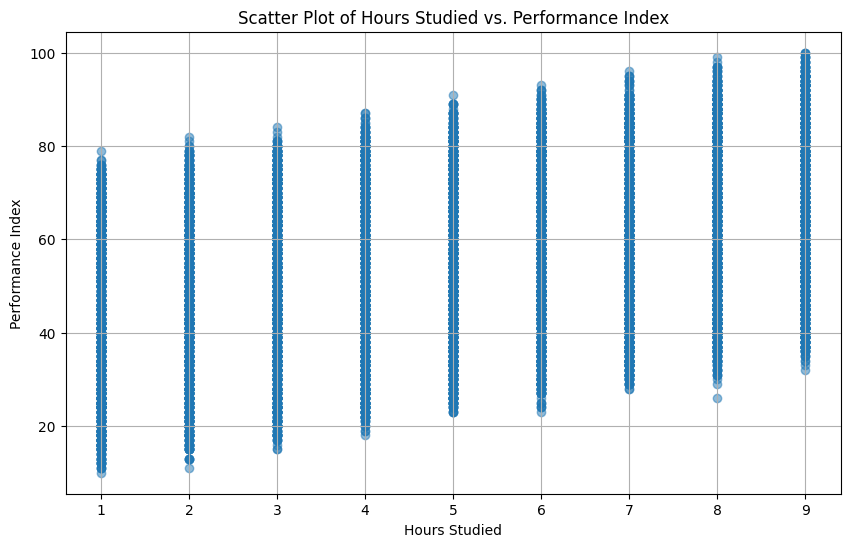

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['Hours Studied'], df['Performance Index'], alpha=0.5)
plt.title('Scatter Plot of Hours Studied vs. Performance Index')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.grid(True)
plt.show()

El grafico de dispersion muestra una clara tendencia lnieal...

Establezca las horas de estudio (Hours_Studied)  com variable dependiente y el (Peformance_Index) como la variaboe dependiente

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Define the independent variable (X) and dependent variable (y)
X = df[['Hours Studied']]
y = df['Performance Index']

# Create a linear regression model
model = LinearRegression()

# Fit the model to the data
model.fit(X, y)

# Display the coefficients and intercept
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Coefficient (Slope): 2.77
Intercept: 41.38


The linear regression model has been fitted. The coefficient (slope) indicates how much 'Performance Index' changes for each unit increase in 'Hours Studied', and the intercept is the expected 'Performance Index' when 'Hours Studied' is zero.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


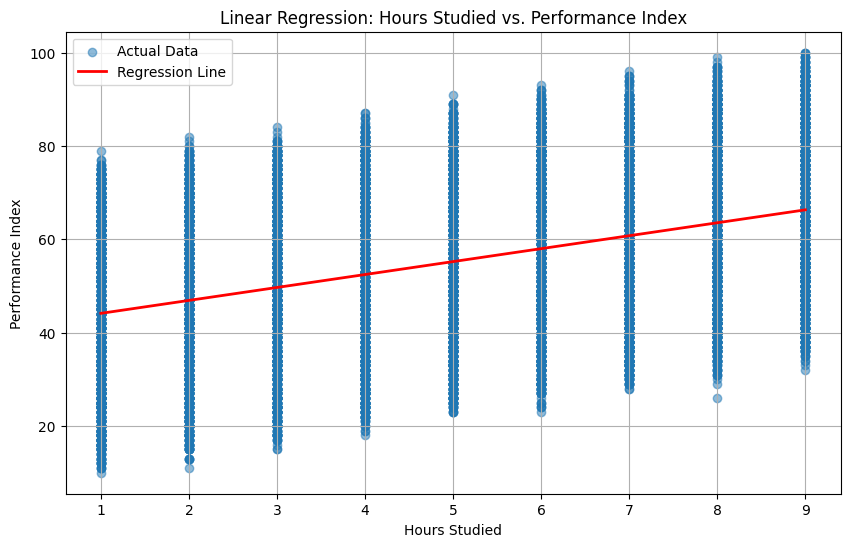

In [ ]:
import matplotlib.pyplot as plt

# Generate predictions for the regression line
X_pred = np.array([X['Hours Studied'].min(), X['Hours Studied'].max()]).reshape(-1, 1)
y_pred = model.predict(X_pred)

# Plot the scatter plot again and add the regression line
plt.figure(figsize=(10, 6))
plt.scatter(df['Hours Studied'], df['Performance Index'], alpha=0.5, label='Actual Data')
plt.plot(X_pred, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Hours Studied vs. Performance Index')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.grid(True)
plt.legend()
plt.show()

La recta de regresio ajsutada obtenida es muy consiente con observaciones. Se esperaba una relacion positiva

In [ ]:
r_squared = model.score(X, y)
print(f"R-squared: {r_squared:.2f}")

R-squared: 0.14


The R-squared value indicates the proportion of the variance in the dependent variable ('Performance Index') that can be predicted from the independent variable ('Hours Studied'). A higher R-squared value indicates a better fit of the model to the data.

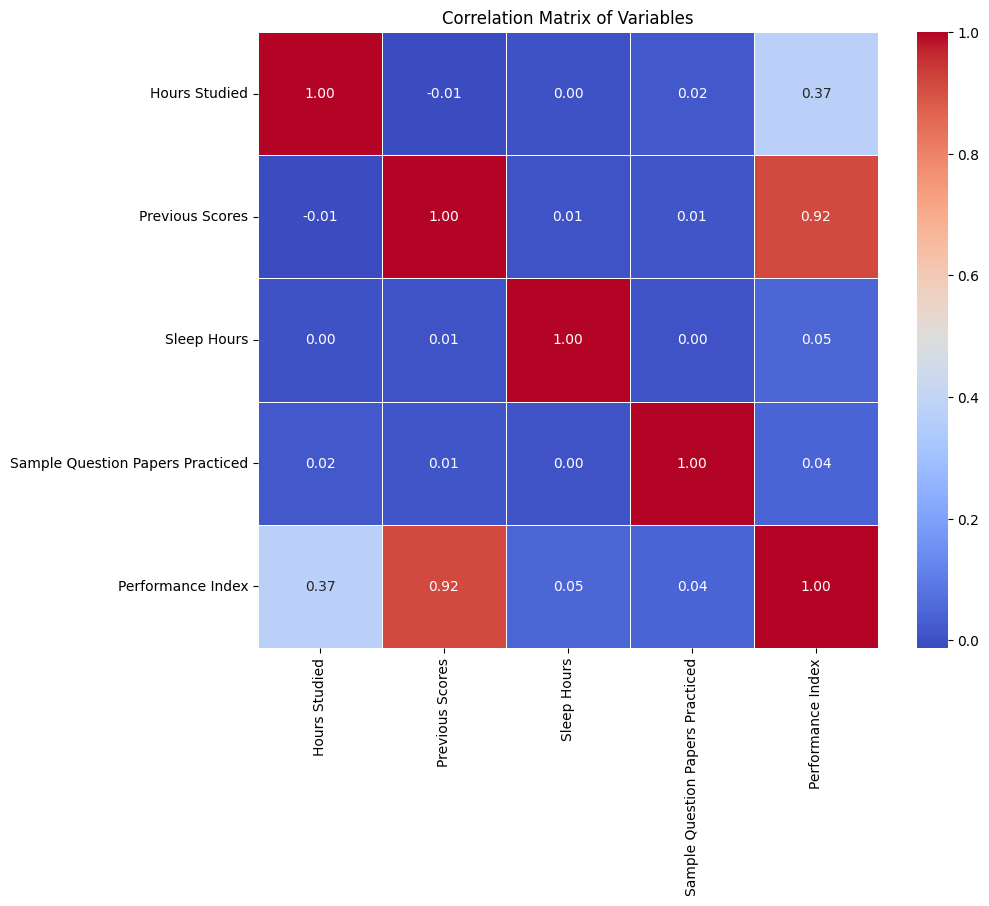

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Variables')
plt.show()

Los residuales parecen reforza la idea de que los datos siguen una tendencia en los colores de la tabla

valor-p (Shapiro) = 0.000


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


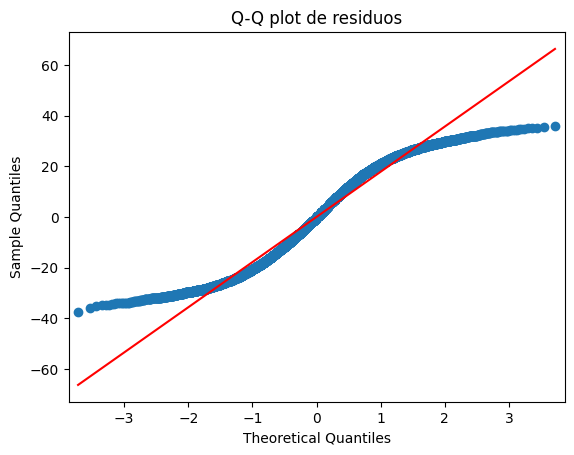

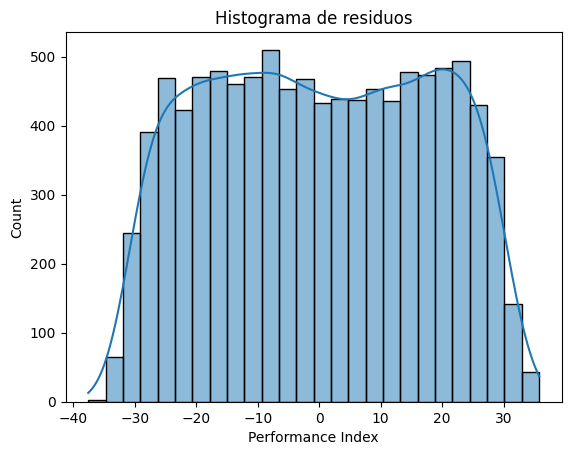

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # Import statsmodels for qqplot

# Calculate predicted values
y_pred_actual = model.predict(X)

# Calculate residuals
residuales = y - y_pred_actual

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh:.3f}") # Formatear a 3 decimales

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

segun el grafico nos muestra una distribucion uniforme y normal

In [ ]:
import statsmodels.formula.api as smf

# Define the formula for the quantile regression.
# We use 'Q("Column Name")' to handle column names with spaces.
formula = 'Q("Performance Index") ~ Q("Hours Studied")'

# Instantiate and fit the Quantile Regression model for the 0.5 (median) quantile
# We'll use the original DataFrame 'df' directly with the formula API
quant_model_median = smf.quantreg(formula, df).fit(q=0.5)

# Display the model summary
print(quant_model_median.summary())

                           QuantReg Regression Results                            
Dep. Variable:     Q("Performance Index")   Pseudo R-squared:              0.04772
Model:                           QuantReg   Bandwidth:                       4.353
Method:                     Least Squares   Sparsity:                        63.01
Date:                    Fri, 03 Jul 2026   No. Observations:                10000
Time:                            04:38:38   Df Residuals:                     9998
                                            Df Model:                            1
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             41.2500      0.684     60.280      0.000      39.909      42.591
Q("Hours Studied")     2.7500      0.122     22.602      0.000       2.512       2.988


Este resumen te muestra los coeficientes del modelo para la mediana (percentil 0.5), sus errores estándar, valores t, p-valores e intervalos de confianza. Puedes comparar estos coeficientes con los obtenidos en la regresión MCO para ver cómo difieren al modelar la mediana en lugar de la media.